# Risk Analysis Tutorials: Week 4

Welcome to the Week 3 tutorial! 👋  

#### ✅ How to use this notebook

1. To save your own progress: Go to **File → Save a copy in Drive** (recommended)
2. The cell below will automatically **download all required data** from the course repository.  
3. You can run cells one by one using the play button on the top left of the cell or `Shift + Enter`.

**⚠️ Note: All work done here is temporary unless you save your own copy. Each time you reopen the notebook, Colab starts a new session.**

In [ ]:
# Execute this cell. Do not modify it! It makes the notebook executable with Google Colab. If you are not using Colab, it will simply print a message.
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install scipy
!pip install ipympl


# 1) Joint PDF

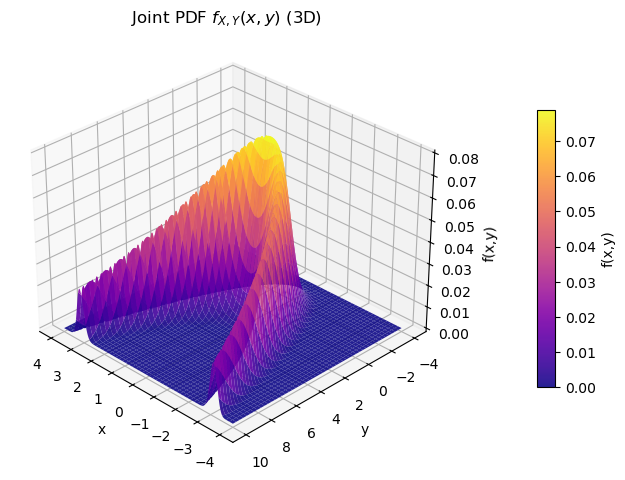

In [7]:
# a. Formulate the joint PDF fXY.
import numpy as np # numpy is a package for efficient numerical operations
from scipy import stats # scipy stats is a package for statistical operations
import matplotlib.pyplot as plt

# Marginal Distribution of X: Normal(0, 2)
def f_X(x):
    return stats.norm(loc=0, scale=2).pdf(x)

# Conditional Distribution of Y given X: Normal(X^2, 1)
def f_Y_given_X(y, x):
    return stats.norm(loc=x**2, scale=1).pdf(y)

# Joint Distribution of X and Y
def f_XY(x, y):
    return f_X(x) * f_Y_given_X(y, x)

# Create a grid of x and y values
x = np.linspace(-4, 4, 600)
y = np.linspace(-4, 10, 600)
X, Y = np.meshgrid(x, y)
Z = f_XY(X, Y)

# For interactive plots you need the widget backend, but it may not work in all environments.
%matplotlib inline
#%matplotlib widget

# Plot as 3D surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=135)  # Change the elevation and azimuthal angle
# Alternatives to 'cmap' include specifying other colormaps such as 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'cool', 'hot', 'spring', etc.
# surf = ax.contour3D(X, Y, Z, levels=30, cmap='plasma', alpha=0.85) 
surf = ax.plot_surface(X, Y, Z, cmap='plasma', edgecolor='none', alpha=0.9)
fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, label='f(x,y)', location='right', pad=0.15)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Joint PDF $f_{X,Y}(x, y)$ (3D)')

# Display the 3D plot
plt.show()


### 1b. Determine the marginal PDF of Y, fY.

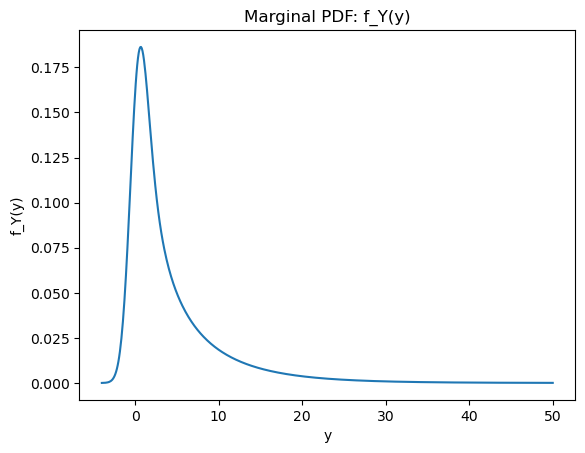

In [ ]:

import numpy as np


def f_Y(x_vals, y):
    # Discretize x, equidistantly spaced
    dx = x_vals[1] - x_vals[0]

    # Approximate integral f_Y = Integral(f_XY(x,y)) dx as a sum:
    return np.sum(f_XY(x_vals, y)) * dx

# Create a grid of x and y values
x_vals = np.linspace(-10, 10, 600)
y_vals = np.linspace(-4, 50, 600)

#To get the f_Y(y) for each y value, compute the marginal PDF f_Y(y)
pdf_vals = []
for y in y_vals:
    pdf_vals.append(f_Y(x_vals,y))


plt.figure()
plt.plot(y_vals, pdf_vals)
plt.title("Marginal PDF: f_Y(y)")
plt.xlabel("y")
plt.ylabel("f_Y(y)")
plt.show()



#### 1c. What is the probability that Y exceeds 10?

Possibility I: Integrate the PDF from 10 to infinity


Possibility II: Calculate the CDF, then P(Y>10) = 1 - CDF(10)

In [ ]:
# Possibility I: Integrate the PDF from 10 to infinity

index_10 = np.abs(y_vals - 10).argmin()
dy = y_vals[1] - y_vals[0]

print(f"The probability of y > 10 is approximately {np.sum(pdf_vals[index_10:])*dy:.4f}")
print(f"Sanity Check: PDF Integral should be 1: {np.sum(pdf_vals)*dy}")

The probability of y > 10 is approximately 0.1164
Sanity Check: PDF Integral should be 1: 0.9995875168538293


(Interpolated) The probability of y > 10 is approximately 0.1146


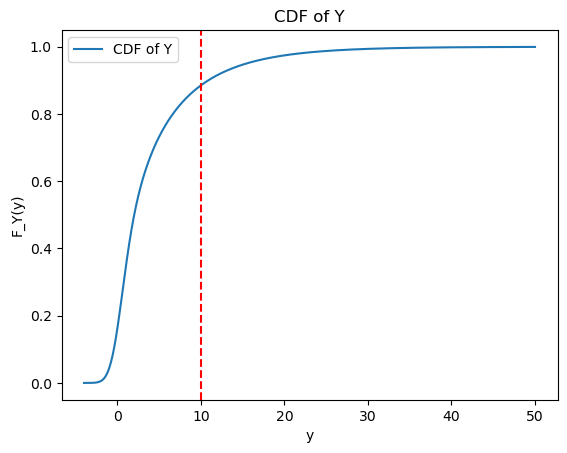

In [ ]:
# Possibility II: Calculate the CDF, then P(Y>10) = 1 - CDF(10)

# since we discretized y, dy will be the same for all y
dy = y_vals[1] - y_vals[0]

# Remember: The CDF is the integral of the PDF.
cdf_vals = np.cumsum(pdf_vals) * dy 


# Interpolate the CDF at y=10
cdf_at_10 = np.interp(10, y_vals, cdf_vals)
pr_y_gt_10_interp = 1 - cdf_at_10

print(f"(Interpolated) The probability of y > 10 is approximately {pr_y_gt_10_interp:.4f}")

plt.figure()
plt.plot(y_vals, cdf_vals, label="CDF of Y")
plt.axvline(10, color="r", linestyle="--")
plt.title("CDF of Y")
plt.xlabel("y")
plt.ylabel("F_Y(y)")
plt.legend()
plt.show()

# 2) Road Junction


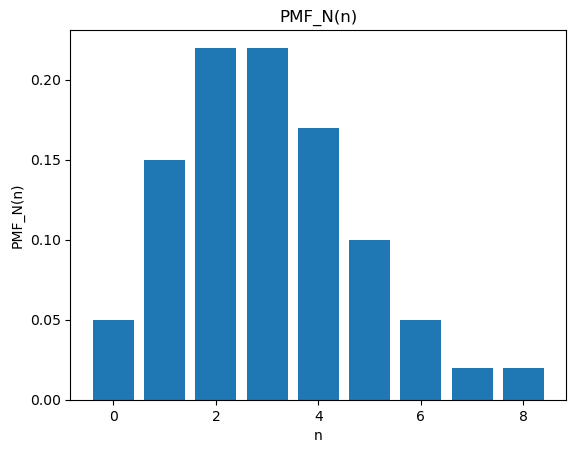

In [11]:
import numpy as np
from scipy.stats import binom

# Parameters
PMF_N = np.array([0.05, 0.15, 0.22, 0.22, 0.17, 0.10, 0.05, 0.02, 0.02])  # P(N=n), n=0..8

plt.figure()
plt.bar(np.arange(9), PMF_N)
plt.title("PMF_N(n)")
plt.xlabel("n")
plt.ylabel("PMF_N(n)")
plt.show()


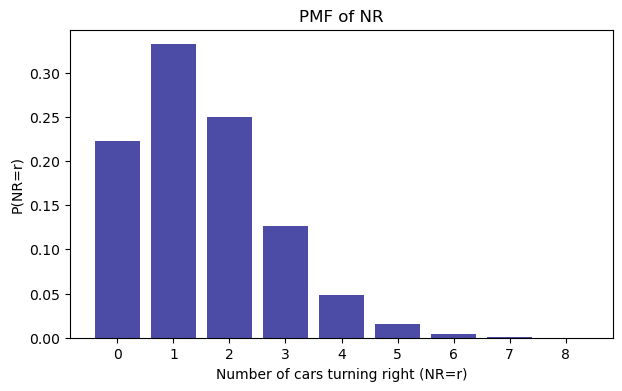

In [16]:
p_r = 0.5  # Probability of turning right

# All possible values of N and NR
nr = np.arange(9) # Number of cars turning right 0..8
n = np.arange(9) # Total number of cars 0..8
N, NR = np.meshgrid(n, nr)

# Conditional PMF P(NR=r | N=n)
p_NR_given_n = binom.pmf(k=NR, n=N, p=p_r)

# Joint PMF P(NR=r, N=n)
p_N_NR = p_NR_given_n * PMF_N

# PMF of Cars Turning Right
p_NR = (p_N_NR).sum(axis=1)

# --- Plot marginal P(NR) ---
plt.figure(figsize=(7, 4))
plt.bar(nr, p_NR, color="navy", alpha=0.7)
plt.xlabel("Number of cars turning right (NR=r)")
plt.ylabel("P(NR=r)")
plt.title("PMF of NR")
plt.xticks(nr)
plt.show()



## Remarks on Task 3: Reservoir Water Levels

In the lecture one of you noticed, that for x=0.5 the following is true: f_Y|X(y|x=0.5) = f_X,Y(X=0.5, Y). However this is just coincidence. For other values this is not the case:

In [17]:
# Define the joint PDF
def f_XY(x, y):
    """
    Joint PDF: f_XY(x, y) = (6/5) * (x + y^2)
    Domain: x in [0, 1], y in [0, 1]
    """
    return (6/5) * (x + y**2)

# Analytical marginal PDFs:
# f_X(x) = ∫₀¹ (6/5)(x + y²) dy = (6/5)[xy + y³/3]₀¹ = (6/5)(x + 1/3) = (6/5)x + 2/5
def f_X(x):
    """Marginal PDF of X: f_X(x) = (6/5)x + 2/5"""
    return (6/5) * x + 2/5

# f_Y(y) = ∫₀¹ (6/5)(x + y²) dx = (6/5)[x²/2 + xy²]₀¹ = (6/5)(1/2 + y²) = 3/5 + (6/5)y²
def f_Y(y):
    """Marginal PDF of Y: f_Y(y) = 3/5 + (6/5)y²"""
    return 3/5 + (6/5) * y**2

def f_Y_given_X(y, x):
    return f_XY(x, y) / f_X(x)

for x_val in np.linspace(0, 1, 5):
    for y_val in np.linspace(0, 1, 5):
        print(f"x = {x_val:.2f}, y = {y_val:.2f} | f_Y_given_X(y|x) - f_XY(x, y) = {f_Y_given_X(y_val, x_val)-f_XY(x_val, y_val):.2f}")


x = 0.00, y = 0.00 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.00, y = 0.25 | f_Y_given_X(y|x) - f_XY(x, y) = 0.11
x = 0.00, y = 0.50 | f_Y_given_X(y|x) - f_XY(x, y) = 0.45
x = 0.00, y = 0.75 | f_Y_given_X(y|x) - f_XY(x, y) = 1.01
x = 0.00, y = 1.00 | f_Y_given_X(y|x) - f_XY(x, y) = 1.80
x = 0.25, y = 0.00 | f_Y_given_X(y|x) - f_XY(x, y) = 0.13
x = 0.25, y = 0.25 | f_Y_given_X(y|x) - f_XY(x, y) = 0.16
x = 0.25, y = 0.50 | f_Y_given_X(y|x) - f_XY(x, y) = 0.26
x = 0.25, y = 0.75 | f_Y_given_X(y|x) - f_XY(x, y) = 0.42
x = 0.25, y = 1.00 | f_Y_given_X(y|x) - f_XY(x, y) = 0.64
x = 0.50, y = 0.00 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.50, y = 0.25 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.50, y = 0.50 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.50, y = 0.75 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.50, y = 1.00 | f_Y_given_X(y|x) - f_XY(x, y) = 0.00
x = 0.75, y = 0.00 | f_Y_given_X(y|x) - f_XY(x, y) = -0.21
x = 0.75, y = 0.25 | f_Y_given_X(y|x) - f_XY(x, y) = -0.22
x = 0.75, y 